In [1]:
import seaborn as sns, matplotlib.pyplot as plt, pandas as pd, numpy as np

from category_encoders import TargetEncoder

from sklearn import set_config
from sklearn.pipeline import Pipeline, make_pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import PolynomialFeatures
import os

import warnings

warnings.filterwarnings('ignore')
iteration = '3'

In [2]:
df = pd.read_csv('../assets/hw_2_2/train.csv')

In [3]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [4]:
df.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [6]:
df['IsActiveMember'].unique()

array([0., 1.])

In [7]:
df['IsActiveMember'] = df['IsActiveMember'].astype(int)

In [8]:
df.duplicated().sum()

0

In [9]:
df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df['CustomerId'].duplicated().sum()

8652

In [11]:
df = df.drop(columns=['CustomerId'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   Surname          15000 non-null  object 
 2   CreditScore      15000 non-null  float64
 3   Geography        15000 non-null  object 
 4   Gender           15000 non-null  object 
 5   Age              15000 non-null  float64
 6   Tenure           15000 non-null  float64
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  float64
 9   HasCrCard        15000 non-null  float64
 10  IsActiveMember   15000 non-null  int32  
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           15000 non-null  float64
dtypes: float64(8), int32(1), int64(1), object(3)
memory usage: 1.4+ MB


In [13]:
df['Exited'].value_counts()

Exited
0.0    11948
1.0     3052
Name: count, dtype: int64

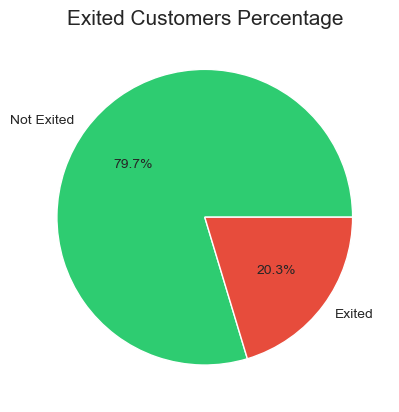

In [14]:
colors = ['#2ECC71', '#E74C3C']

plt.pie(
    df['Exited'].value_counts(),
    labels=['Not Exited', 'Exited'],
    colors=colors,
    shadow=False,
    autopct='%1.1f%%'
)
plt.title('Exited Customers Percentage', fontsize=15)
plt.show()

In [15]:
df['Surname'].value_counts()

Surname
Ch'iu      252
Ch'ien     241
Ch'ang     225
Hsia       204
T'ien      187
          ... 
Trejo        1
Purdy        1
Otoole       1
Sarratt      1
Liardet      1
Name: count, Length: 764, dtype: int64

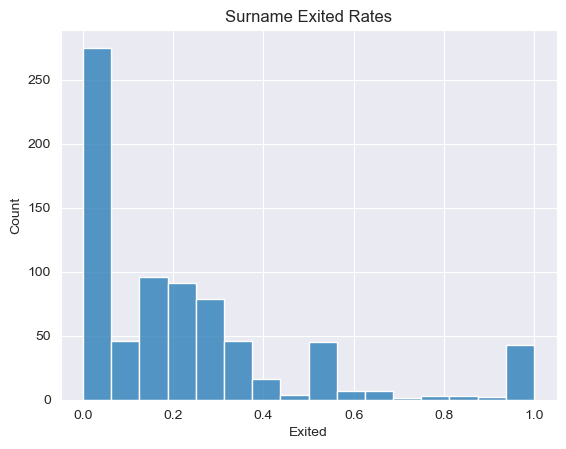

In [16]:
sns.histplot(df.groupby('Surname')['Exited'].mean().sort_values(ascending=False))
plt.title('Surname Exited Rates')
plt.show()

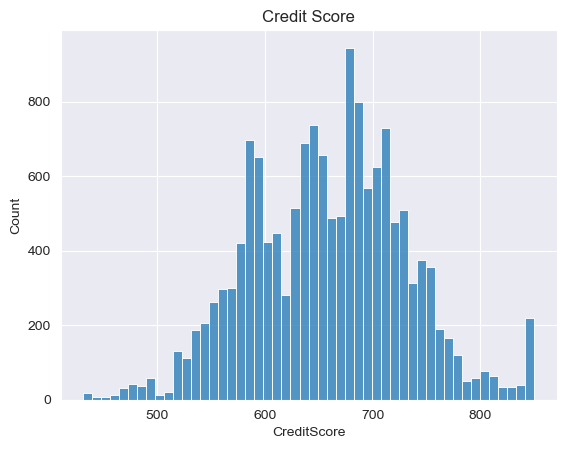

In [17]:
sns.histplot(df['CreditScore'])
plt.title('Credit Score')
plt.show()

In [18]:
df['Geography'].value_counts()

Geography
France     9032
Spain      3303
Germany    2665
Name: count, dtype: int64

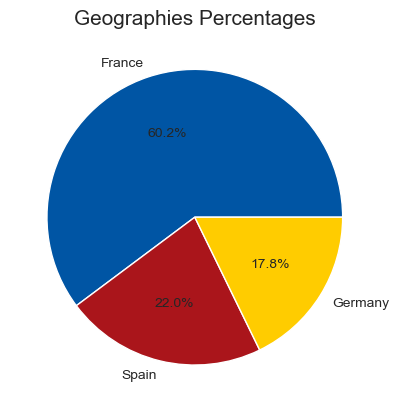

In [19]:
flag_colors = {
    'France': '#0055A4',
    'Germany': '#FFCC00',
    'Spain': '#AA151B'
}

labels = df['Geography'].value_counts().index.tolist()
colors = [flag_colors[label] for label in labels]

plt.pie(
    df['Geography'].value_counts(),
    labels=labels,
    colors=colors,
    shadow=False,
    autopct='%1.1f%%'
)
plt.title('Geographies Percentages', fontsize=15)
plt.show()

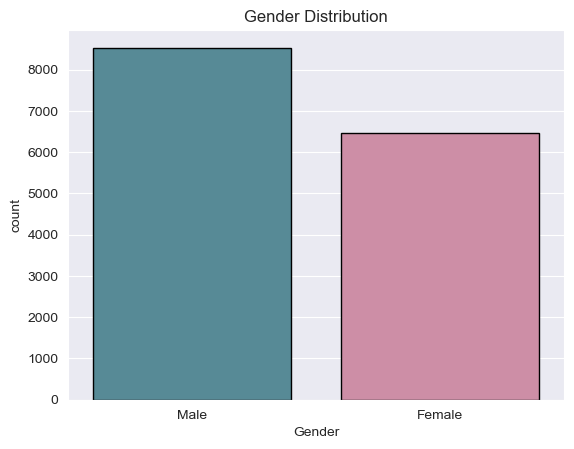

In [20]:
custom_palette = {'Male': '#4D90A0', 'Female': '#D883A3'}

sns.countplot(data=df, x='Gender', edgecolor='black', palette=custom_palette)
plt.title('Gender Distribution')
plt.show()

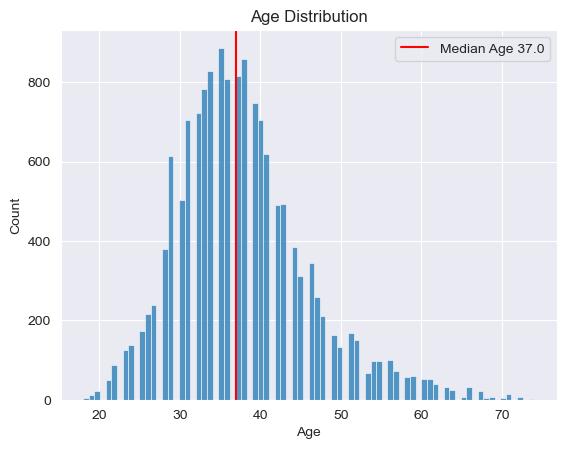

In [21]:
sns.histplot(data=df, x='Age', bins=80)
plt.axvline(df['Age'].median(), color='r', label=f"Median Age {df['Age'].median()}")
plt.title('Age Distribution');
plt.legend()
plt.show()

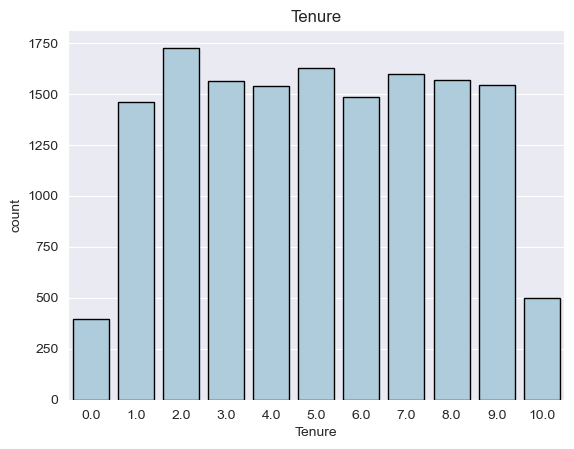

In [22]:
sns.countplot(data=df, x='Tenure', color='#A6CEE3', edgecolor='black')
plt.title('Tenure');
plt.show()

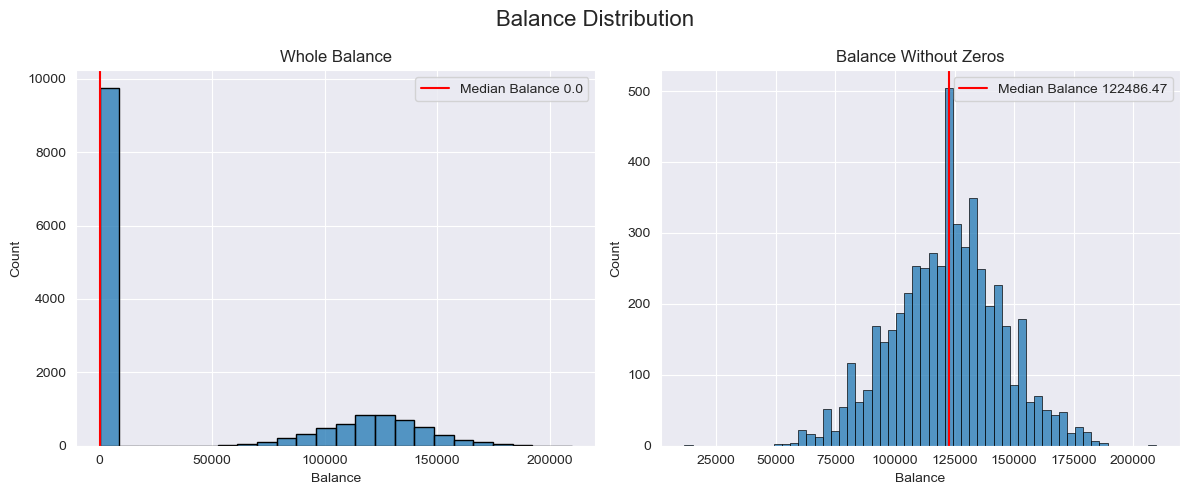

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x='Balance', ax=ax[0], edgecolor='black')
sns.histplot(data=df[df['Balance'] != 0], x='Balance', ax=ax[1], edgecolor='black')
ax[0].axvline(df['Balance'].median(), color='r', label=f"Median Balance {df['Balance'].median()}")
ax[0].set_title('Whole Balance')

kk = df[df['Balance'] != 0]['Balance'].median()
ax[1].axvline(kk, color='r', label=f"Median Balance {kk}")
ax[1].set_title('Balance Without Zeros')
fig.suptitle('Balance Distribution', fontsize=16);
ax[0].legend();
ax[1].legend();
fig.tight_layout()
plt.show()

In [24]:
df['Balance'].value_counts()

Balance
0.00         9742
122314.50      15
123544.00      14
102773.20      12
127864.40      11
             ... 
131081.66       1
144705.87       1
107868.14       1
124125.26       1
139129.42       1
Name: count, Length: 3395, dtype: int64

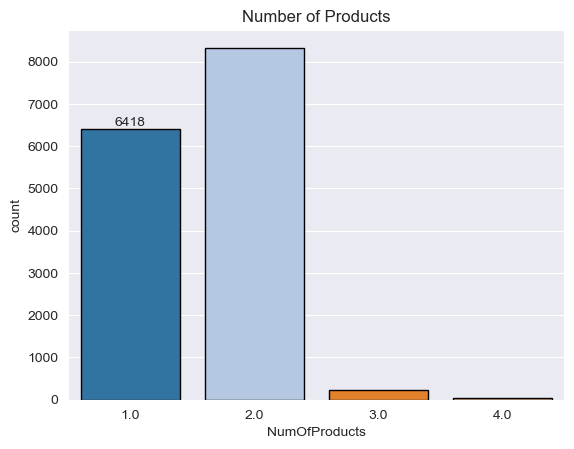

In [25]:
g = sns.countplot(data=df, x='NumOfProducts', palette='tab20', edgecolor='black')
g.bar_label(g.containers[0])
plt.title('Number of Products')
plt.show()

In [26]:
df['IsActiveMember'].value_counts()

IsActiveMember
0    7655
1    7345
Name: count, dtype: int64

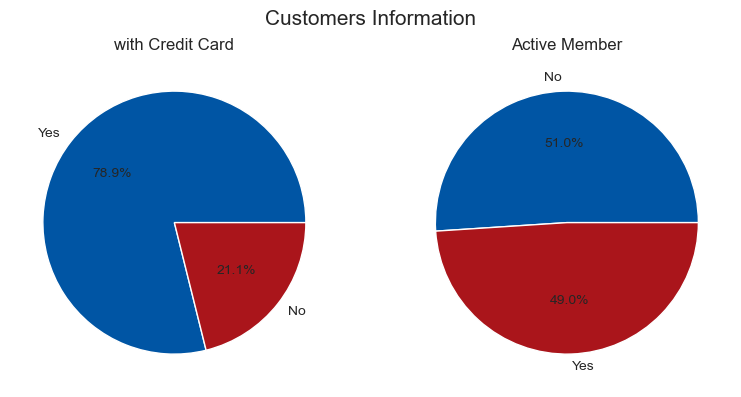

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
sns.set_palette('Blues', 3)
ax[0].pie(df['HasCrCard'].value_counts(), labels=['Yes', 'No'], colors=colors, shadow=False, autopct='%1.1f%%')
ax[0].set_title('with Credit Card')
ax[1].pie(df['IsActiveMember'].value_counts(), labels=['No', 'Yes'], colors=colors, shadow=False, autopct='%1.1f%%')
ax[1].set_title('Active Member')

fig.suptitle('Customers Information', fontsize=15)
fig.tight_layout()
plt.show()

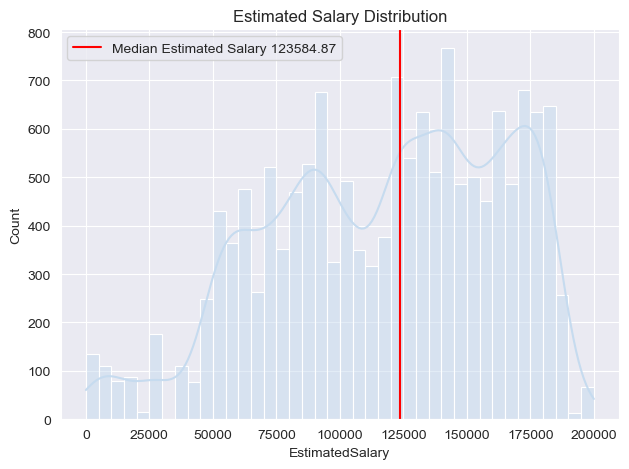

In [28]:
sns.histplot(data=df, x='EstimatedSalary', bins=40, kde=True)
plt.axvline(df['EstimatedSalary'].median(), color='r',
            label=f"Median Estimated Salary {df['EstimatedSalary'].median()}")

plt.title('Estimated Salary Distribution')
plt.tight_layout()
plt.legend()
plt.show()

In [29]:
df.groupby('Geography')['Exited'].mean()

Geography
France     0.159212
Germany    0.413508
Spain      0.155011
Name: Exited, dtype: float64

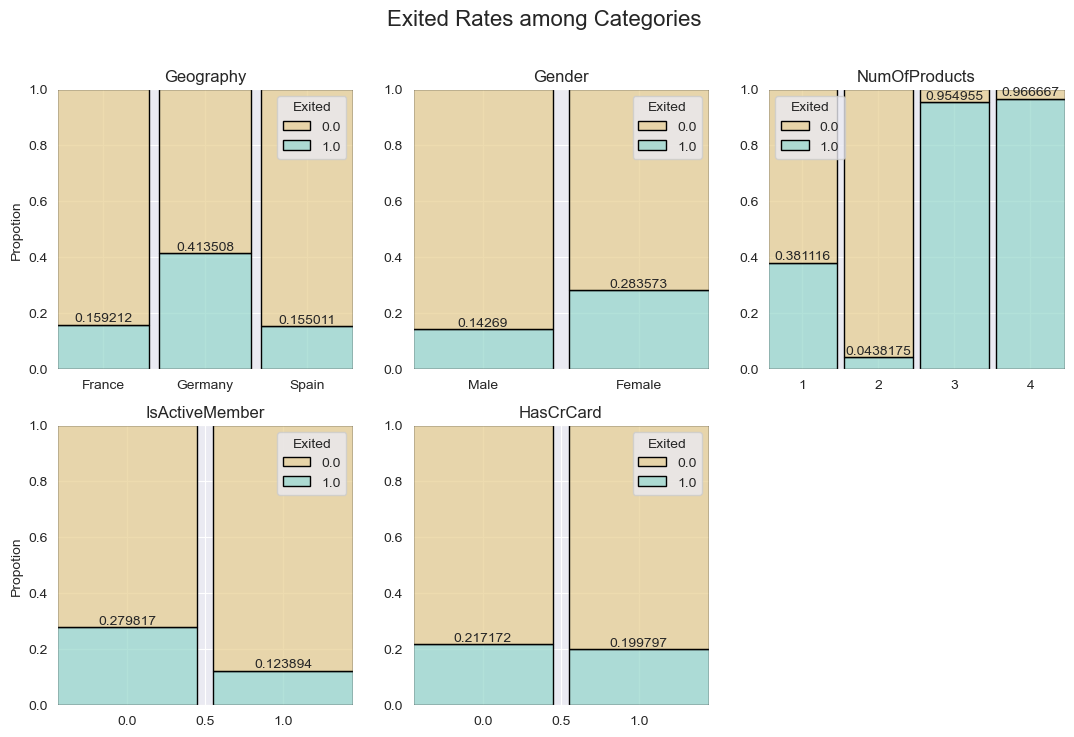

In [30]:
plt.figure(figsize=(13, 8))
for i, c in enumerate(['Geography', 'Gender', 'NumOfProducts', 'IsActiveMember', 'HasCrCard']):
    plt.subplot(2, 3, i + 1)
    ax = sns.histplot(x=c, hue='Exited', data=df, palette='BrBG', edgecolor='black'
                      , multiple='fill', discrete=True, shrink=.9)
    ax.bar_label(ax.containers[0])
    ax.set_xlabel('')
    ax.set_title(c)
    if i % 3 == 0:
        ax.set_ylabel('Propotion')
    else:
        ax.set_ylabel('')

plt.suptitle('Exited Rates among Categories', size=16)
fig.tight_layout()
plt.show()

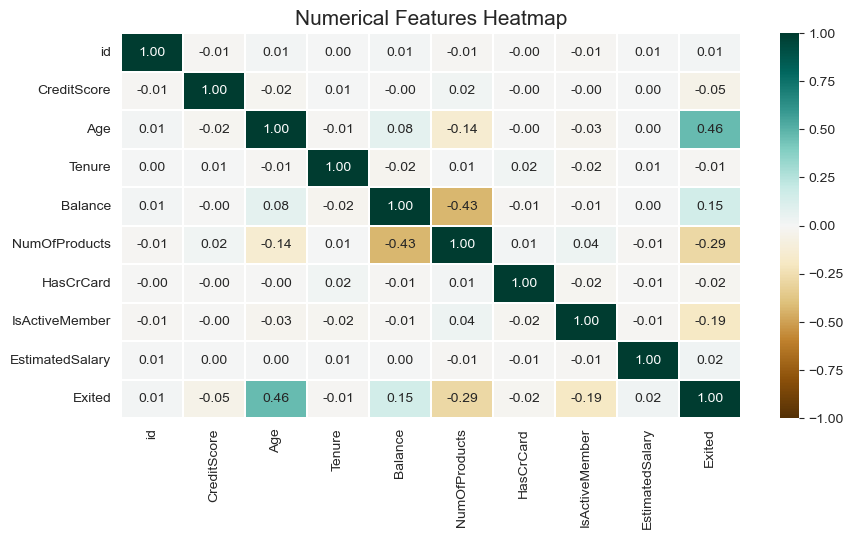

In [31]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), cmap='BrBG', center=0, annot=True, vmin=-1, fmt='.2f', linewidths=.1)
plt.title('Numerical Features Heatmap', size=15)
plt.show()

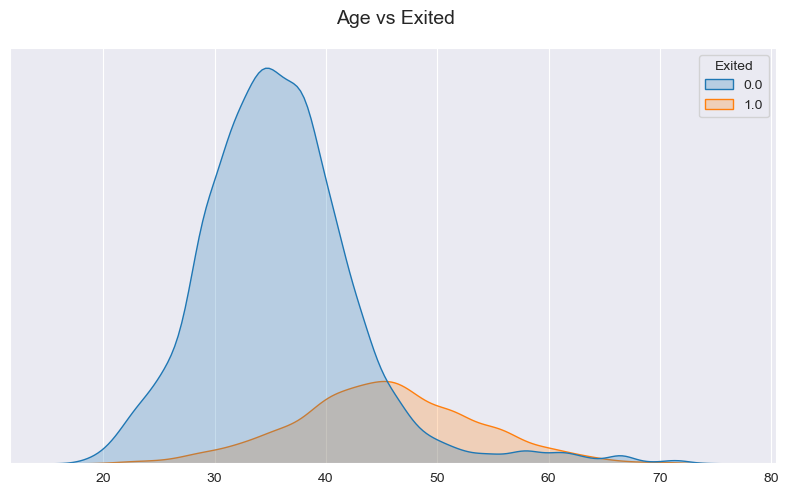

In [32]:
sns.set_palette('tab10')

fig = plt.figure(figsize=(8, 5))
g = sns.kdeplot(data=df, x='Age', hue='Exited', label='Exited', fill=True)
g.set_xlabel('')
g.set_ylabel('')
plt.yticks([])

fig.suptitle(f"Age vs Exited", fontsize=14)
fig.tight_layout()
plt.show()

In [33]:
t_encoder = TargetEncoder()
df['SurnameExitedRate'] = t_encoder.fit_transform(df['Surname'], df['Exited'])

<Figure size 1200x1200 with 0 Axes>

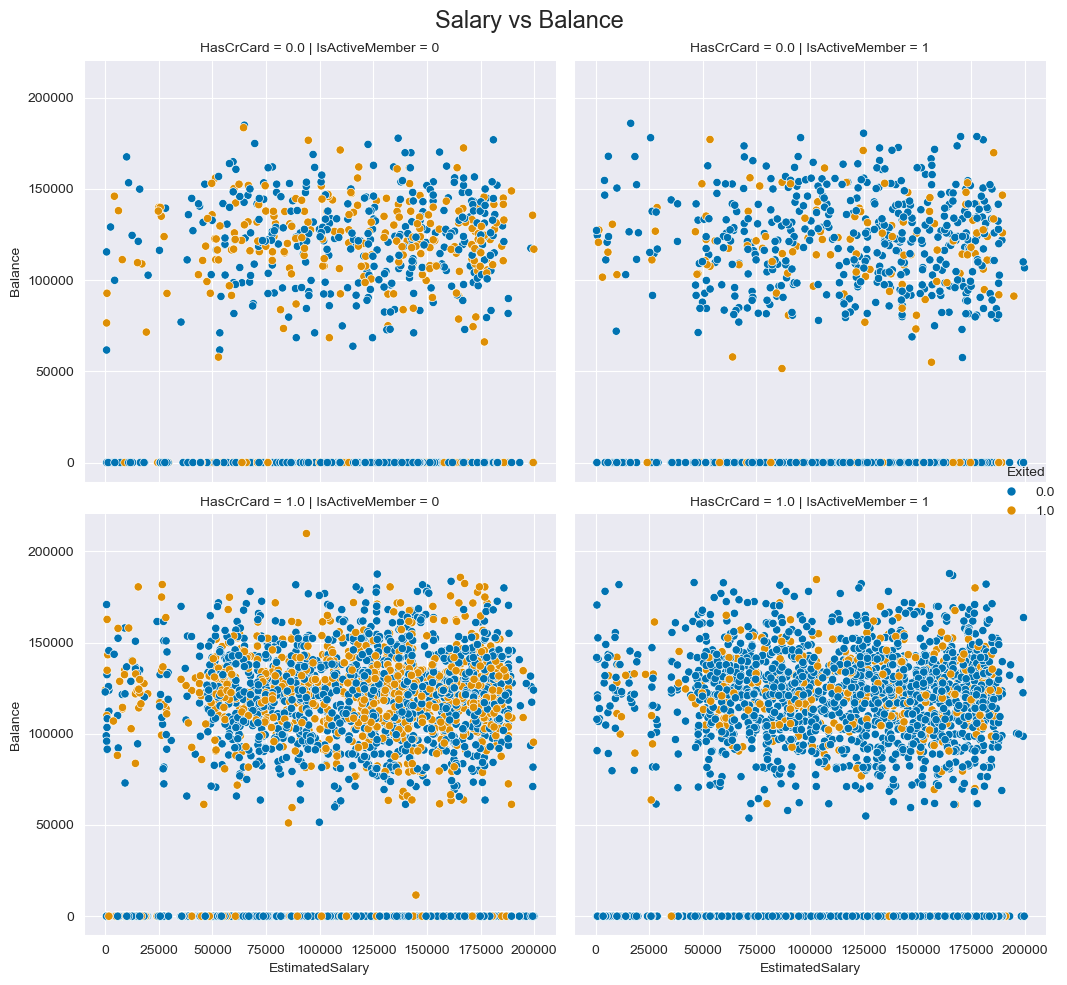

In [34]:
plt.figure(figsize=(12, 12))
sns.relplot(data=df, x='EstimatedSalary', y='Balance', hue='Exited', col='IsActiveMember', row='HasCrCard',
            kind='scatter', palette=sns.color_palette('colorblind', 2))
plt.suptitle('Salary vs Balance', fontsize=17)
plt.tight_layout()
plt.show()

In [35]:
df.groupby(['HasCrCard', 'IsActiveMember'])['Exited'].mean()

HasCrCard  IsActiveMember
0.0        0                 0.290219
           1                 0.146840
1.0        0                 0.277168
           1                 0.117432
Name: Exited, dtype: float64

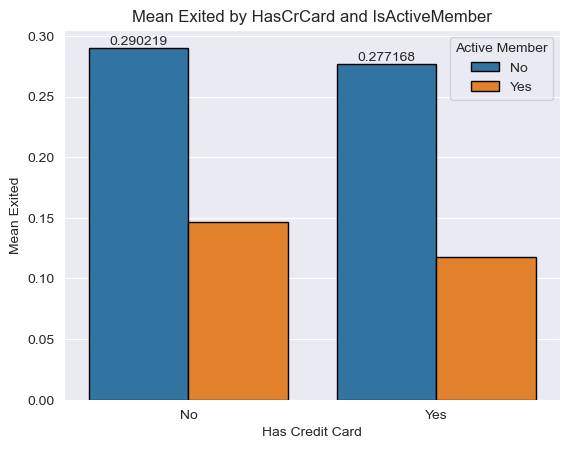

In [36]:
a = sns.barplot(x='HasCrCard', y='Exited', hue='IsActiveMember', data=df, ci=None, edgecolor='black')

a.bar_label(a.containers[0])

plt.title('Mean Exited by HasCrCard and IsActiveMember')
plt.xlabel('Has Credit Card')
plt.ylabel('Mean Exited')
plt.xticks([0, 1], ['No', 'Yes'])
plt.legend(title='Active Member', loc='upper right', labels=['No', 'Yes'])

plt.show()

In [37]:
df['ActiveCrCard'] = df['HasCrCard'] + (df['IsActiveMember'])

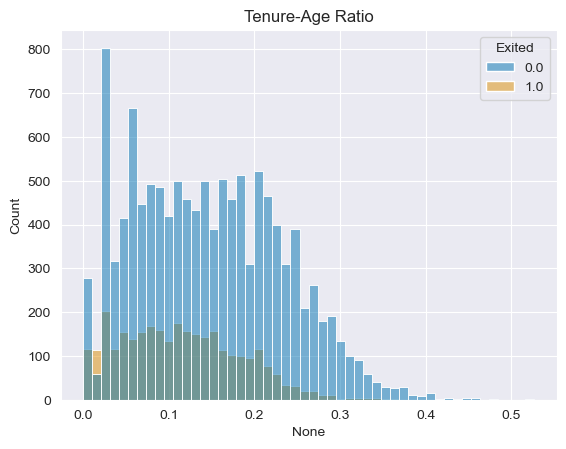

In [38]:
sns.histplot(x=df['Tenure'] / df['Age'], data=df, hue='Exited', palette='colorblind')
plt.title("Tenure-Age Ratio")
plt.show()

In [39]:
df['TenureAgeRatio'] = df['Tenure'] / df['Age']

In [40]:
df.groupby('Tenure')['Exited'].mean()

Tenure
0.0     0.294416
1.0     0.219562
2.0     0.172654
3.0     0.208200
4.0     0.214286
5.0     0.209459
6.0     0.201211
7.0     0.173041
8.0     0.195791
9.0     0.224887
10.0    0.185111
Name: Exited, dtype: float64

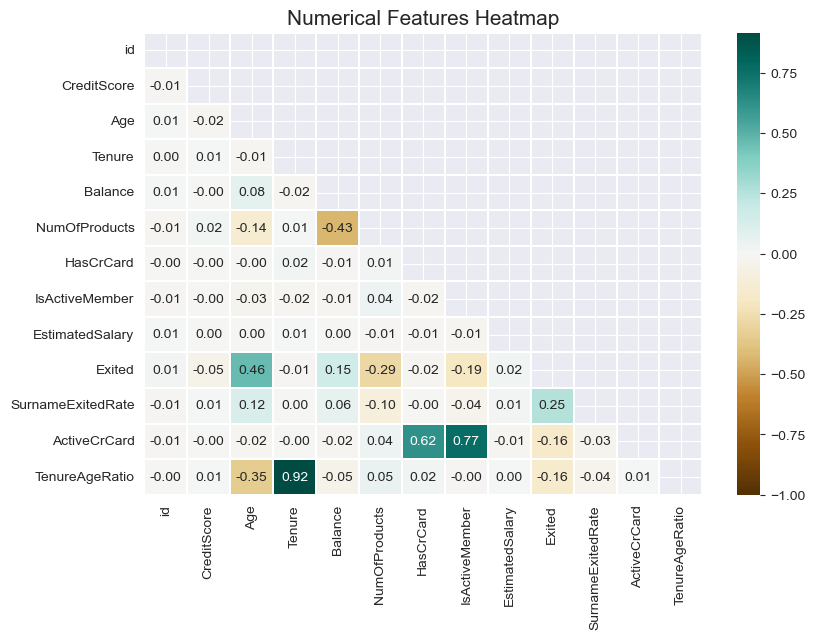

In [41]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), mask=np.triu(df.select_dtypes(exclude=[object]).corr()), cmap='BrBG', center=0,
            annot=True, vmin=-1, fmt='.2f', linewidths=.1)
plt.title('Numerical Features Heatmap', size=15)
plt.show()

In [42]:
set_config(transform_output='pandas')

X, y = df.drop(columns=['Exited']), df['Exited']

X_train, xtemp, y_train, ytemp = train_test_split(X, y, test_size=.3, stratify=y, random_state=3)
X_valid, X_test, y_valid, y_test = train_test_split(xtemp, ytemp, test_size=.5, stratify=ytemp, random_state=322)

In [43]:
print('Training set Shape: ', X_train.shape, y_train.shape)
print('Validation set Shape: ', X_valid.shape, y_valid.shape)
print('Testing set Shape: ', X_test.shape, y_test.shape)
print('\n\n')
print('\nTrain Target Dist: ', y_train.value_counts())
print('\nValid Target Dist: ', y_valid.value_counts)
print('\nTest Target Dist: ', y_test.value_counts())

Training set Shape:  (10500, 15) (10500,)
Validation set Shape:  (2250, 15) (2250,)
Testing set Shape:  (2250, 15) (2250,)




Train Target Dist:  Exited
0.0    8364
1.0    2136
Name: count, dtype: int64

Valid Target Dist:  <bound method IndexOpsMixin.value_counts of 2790     0.0
6163     1.0
6264     0.0
7704     0.0
3150     1.0
        ... 
7391     0.0
14171    1.0
11498    1.0
8677     1.0
7699     0.0
Name: Exited, Length: 2250, dtype: float64>

Test Target Dist:  Exited
0.0    1792
1.0     458
Name: count, dtype: int64


In [44]:
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
])
num_poly_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])
target_enc_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', TargetEncoder())
])


def ActiveCrCardFunc(d):
    d['ActiveCrCard'] = d['HasCrCard'] + (4 * d['IsActiveMember']) + 1
    return d[['ActiveCrCard']]


def TenurebyAgeFunc(d):
    d['Age'] = np.log(d['Age'])
    d['TenureAgeRatio'] = d['Tenure'] / d['Age']
    return d[['TenureAgeRatio']]


ActiveCrCard_pipeline = make_pipeline(num_pipeline, FunctionTransformer(ActiveCrCardFunc, validate=False))
TenureAge_pipeline = make_pipeline(num_pipeline, FunctionTransformer(TenurebyAgeFunc, validate=False))

preprocessing = ColumnTransformer([
    ('N', num_poly_pipeline, ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure']),
    ('ActiveCrCard', ActiveCrCard_pipeline, ['IsActiveMember', 'HasCrCard']),
    ('TenureAgeR', TenureAge_pipeline, ['Age', 'Tenure']),
    ('Age', make_pipeline(num_pipeline, FunctionTransformer(func=np.log)), ['Age']),
    ('Cat', cat_pipeline, ['Geography', 'Gender', 'NumOfProducts']),
    ('Tar', target_enc_pipeline, ['Surname', 'NumOfProducts', 'Gender', 'Geography']),
], remainder='drop', verbose_feature_names_out=False)

preprocessing = Pipeline([
    ('Preprocessing for columns', preprocessing),
    ('Scaling', StandardScaler())
])

# preprocessing = ColumnTransformer([
#     ('numerical',num_pipeline,['CreditScore','Balance','EstimatedSalary','Tenure']),
#     ('ActiveCrCard',ActiveCrCard_pipeline,['IsActiveMember','HasCrCard']),
#     ('Age',make_pipeline(num_pipeline,FunctionTransformer(func=np.log)),['Age']),
#     ('category',cat_pipeline,['Geography','Gender','NumOfProducts']),
#     ('surname',surname_pipeline,['Surname']),
# ],remainder='drop',verbose_feature_names_out=False)

# preprocessing = Pipeline([
#     ('Preprocessing for columns',preprocessing),
#     ('Scaling',StandardScaler())
# ])

In [45]:
train_prepared = preprocessing.fit_transform(X_train, y_train).replace(0, -1)
valid_prepared = preprocessing.transform(X_valid).replace(0, -1)
test_prepared = preprocessing.transform(X_test).replace(0, -1)

train_prepared.sample(2)

,CreditScore,Balance,EstimatedSalary,Tenure,CreditScore^2,CreditScore Balance,CreditScore EstimatedSalary,CreditScore Tenure,Balance^2,Balance EstimatedSalary,...,Geography_Germany,Geography_Spain,Gender_Male,NumOfProducts_2.0,NumOfProducts_3.0,NumOfProducts_4.0,Surname,NumOfProducts,Gender,Geography
12280,-0.248350,1.243009,-0.142896,-1.089564,-0.298182,1.180445,-0.200157,-1.081623,1.029133,1.021896,...,2.151399,-0.531394,-1.148057,-1.117531,-0.122566,-0.044766,-2.023555,0.930251,1.148057,2.151078
12672,-1.327882,1.896069,-1.166256,-0.009100,-1.279125,1.503946,-1.311482,-0.265030,2.350924,0.642598,...,-0.464814,-0.531394,0.871037,-1.117531,-0.122566,-0.044766,0.970214,0.930251,-0.871037,-0.453224


In [47]:
rfmodel = RandomForestClassifier(n_estimators=200, random_state=3, max_depth=10)
rfmodel.fit(train_prepared, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
def evaluate_model(model):
    tr_preds = model.predict(train_prepared)
    print('Train Accuracy', accuracy_score(y_train, tr_preds))
    ts_preds = model.predict(valid_prepared)
    print('Validation Accuracy', accuracy_score(y_valid, ts_preds))
    print('\n')
    ts_preds = model.predict_proba(valid_prepared)[:, 1]
    tr_preds = model.predict_proba(train_prepared)[:, 1]
    print('Train AUC Score', roc_auc_score(y_train, tr_preds))
    print('Validation AUC Score', roc_auc_score(y_valid, ts_preds))


evaluate_model(rfmodel)

Train Accuracy 0.9390666666666667
Validation Accuracy 0.9391111111111111


Train AUC Score 0.97756974192668
Validation AUC Score 0.9750504425296319


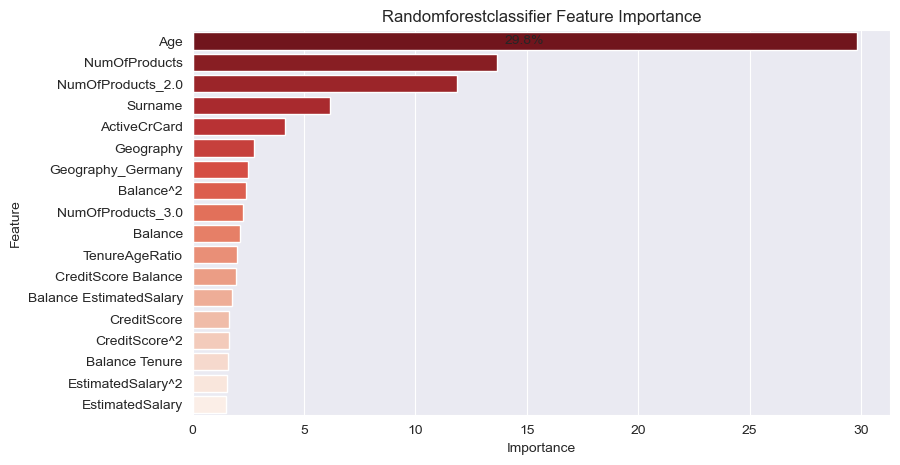

In [50]:
def plot_feature_importance(model):
    feature_importances = model.feature_importances_
    model_name = type(model).__name__
    feature_importance_df = pd.DataFrame({'Feature': train_prepared.columns,
                                          'Importance': feature_importances}).sort_values(by='Importance',
                                                                                          ascending=False)
    plt.figure(figsize=(9, 5))
    a = sns.barplot(y=feature_importance_df['Feature'][:18], x=feature_importance_df['Importance'][:18] * 100,
                    palette='Reds_r')
    heights = [str(round(height, 1)) + '%' for height in a.containers[0].datavalues]
    a.bar_label(a.containers[0], labels=heights, label_type='center')
    plt.title(f'{model_name.capitalize()} Feature Importance')
    plt.show()


plot_feature_importance(rfmodel)

In [51]:
tt_preds = rfmodel.predict_proba(test_prepared)[:, 1]
print('Test AUC Score', roc_auc_score(y_test, tt_preds))

Test AUC Score 0.9750321662507797


In [52]:
test_data = pd.read_csv('../assets/hw_2_2/test.csv')
CustomerID = test_data['id']
test_data = preprocessing.transform(test_data)
preds = rfmodel.predict_proba(test_data)[:, 1]

In [53]:
submission = pd.DataFrame({'id': CustomerID, 'Exited': preds})
submission.to_csv(iteration + '_submission_rf.csv', index=False)
submission

,id,Exited
0,15000,0.148913
1,15001,0.013209
2,15002,0.022483
3,15003,0.769789
4,15004,0.032218
...,...,...
9995,24995,0.023759
9996,24996,0.016029
9997,24997,0.011792
9998,24998,0.060347


In [54]:
xgmodel = XGBClassifier(n_estimators=1500, verbose=0, learning_rate=.009, njobs=-1, random_state=3)
xgmodel.fit(train_prepared, y_train, eval_set=[(valid_prepared, y_valid)], eval_metric='auc', early_stopping_rounds=30)

[20:27:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "njobs", "verbose" } are not used.

[0]	validation_0-auc:0.92293
[1]	validation_0-auc:0.92631
[2]	validation_0-auc:0.92603
[3]	validation_0-auc:0.92641
[4]	validation_0-auc:0.92617
[5]	validation_0-auc:0.92642
[6]	validation_0-auc:0.92613
[7]	validation_0-auc:0.92651
[8]	validation_0-auc:0.92618
[9]	validation_0-auc:0.92653
[10]	validation_0-auc:0.92664
[11]	validation_0-auc:0.92976
[12]	validation_0-auc:0.93062
[13]	validation_0-auc:0.93061
[14]	validation_0-auc:0.93102
[15]	validation_0-auc:0.93123
[16]	validation_0-auc:0.93123
[17]	validation_0-auc:0.93122
[18]	validation_0-auc:0.93135
[19]	validation_0-auc:0.93124
[20]	validation_0-auc:0.93157
[21]	validation_0-auc:0.93151
[22]	validation_0-auc:0.93170
[23]	validation_0-auc:0.93151
[24]	validation_0-auc:0.93198
[25]	validation_0-auc:0.93198
[26]	validation_0-auc:0.

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [55]:
evaluate_model(xgmodel)

Train Accuracy 0.9470666666666666
Validation Accuracy 0.9435555555555556


Train AUC Score 0.981989670397849
Validation AUC Score 0.9791260527136618


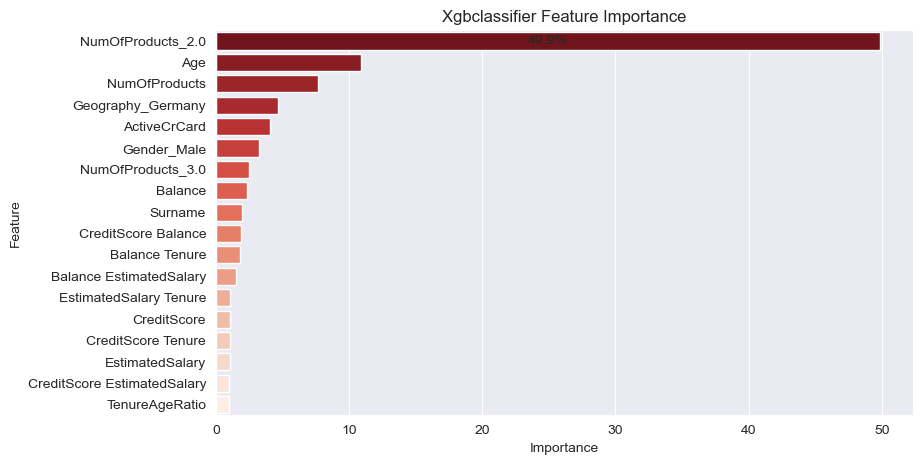

In [56]:
plot_feature_importance(xgmodel)

In [57]:
preds = xgmodel.predict_proba(test_data)[:, 1]
submission = pd.DataFrame({'id': CustomerID, 'Exited': preds})
submission.to_csv(iteration + '_submission_xgb.csv', index=False)
submission

,id,Exited
0,15000,0.086987
1,15001,0.033294
2,15002,0.021645
3,15003,0.921273
4,15004,0.034494
...,...,...
9995,24995,0.017658
9996,24996,0.012540
9997,24997,0.000907
9998,24998,0.058854


In [58]:
lgmodel = LGBMClassifier(learning_rate=0.0088, max_depth=16, n_estimators=2000, num_leaves=16, random_state=3)
lgmodel.fit(train_prepared, y_train, eval_set=[(valid_prepared, y_valid)], eval_metric='auc')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3052, number of negative: 11948
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000836 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3671
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 27
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203467 -> initscore=-1.364767
[LightGBM] [Info] Start training from score -1.364767


,boosting_type,'gbdt'
,num_leaves,16
,max_depth,16
,learning_rate,0.0088
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [59]:
evaluate_model(lgmodel)

Train Accuracy 0.9378666666666666
Validation Accuracy 0.936


Train AUC Score 0.9766497987566041
Validation AUC Score 0.9741512496101061


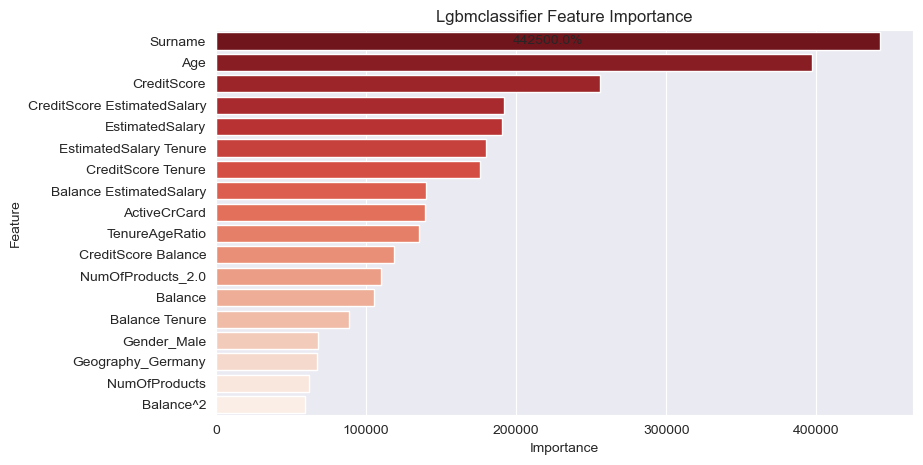

In [60]:
plot_feature_importance(lgmodel)

In [61]:
tt_preds = lgmodel.predict_proba(test_prepared)[:, 1]
print('Test AUC Score', roc_auc_score(y_test, tt_preds))

Test AUC Score 0.9748762086712413


In [62]:
preds = lgmodel.predict_proba(test_data)[:, 1]
submission = pd.DataFrame({'id': CustomerID, 'Exited': preds})
submission.to_csv(iteration + '_submission_lgbm.csv', index=False)
submission

,id,Exited
0,15000,0.060546
1,15001,0.033435
2,15002,0.023444
3,15003,0.834804
4,15004,0.033128
...,...,...
9995,24995,0.009217
9996,24996,0.009822
9997,24997,0.001068
9998,24998,0.051219


In [63]:
cat_model = CatBoostClassifier(
    eval_metric='AUC',
    learning_rate=0.0009,
    iterations=9000,
    random_seed=3
)

cat_model.fit(train_prepared, y_train, eval_set=(valid_prepared, y_valid), verbose=1000)

0:	test: 0.9192103	best: 0.9192103 (0)	total: 152ms	remaining: 22m 47s
1000:	test: 0.9384077	best: 0.9384077 (1000)	total: 5.37s	remaining: 42.9s
2000:	test: 0.9424529	best: 0.9424529 (2000)	total: 9.3s	remaining: 32.5s
3000:	test: 0.9452309	best: 0.9452309 (3000)	total: 13.2s	remaining: 26.5s
4000:	test: 0.9471011	best: 0.9471011 (4000)	total: 17.4s	remaining: 21.8s
5000:	test: 0.9485571	best: 0.9485571 (4999)	total: 21.4s	remaining: 17.1s
6000:	test: 0.9498206	best: 0.9498243 (5999)	total: 25.4s	remaining: 12.7s
7000:	test: 0.9509087	best: 0.9509087 (7000)	total: 29.3s	remaining: 8.36s
8000:	test: 0.9519870	best: 0.9519894 (7998)	total: 33.2s	remaining: 4.15s
8999:	test: 0.9529118	best: 0.9529130 (8996)	total: 37.2s	remaining: 0us

bestTest = 0.9529129952
bestIteration = 8996

Shrink model to first 8997 iterations.


In [64]:
evaluate_model(cat_model)

Train Accuracy 0.9194
Validation Accuracy 0.9182222222222223


Train AUC Score 0.9557166079222285
Validation AUC Score 0.952912995165315


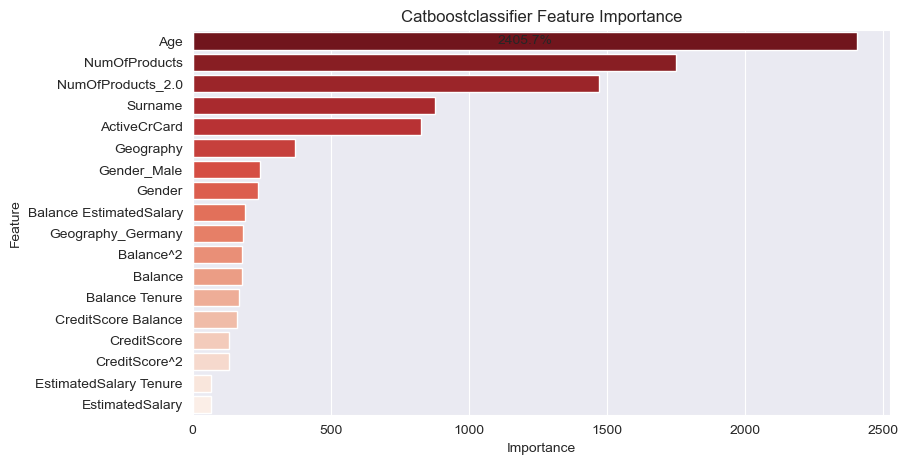

In [65]:
plot_feature_importance(cat_model)

In [66]:
tt_preds = cat_model.predict_proba(test_prepared)[:, 1]
print('Test AUC Score', roc_auc_score(y_test, tt_preds))

Test AUC Score 0.9520162390829696


In [67]:
preds = cat_model.predict_proba(test_data)[:, 1]
submission = pd.DataFrame({'id': CustomerID, 'Exited': preds})
submission.to_csv(iteration + '_submission_cat.csv', index=False)
submission

,id,Exited
0,15000,0.054398
1,15001,0.020858
2,15002,0.028986
3,15003,0.857300
4,15004,0.033321
...,...,...
9995,24995,0.004218
9996,24996,0.005933
9997,24997,0.004155
9998,24998,0.081669
